In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [5]:
X,y = make_regression(n_samples=1000,n_features=1,noise=25,shuffle=True)

In [6]:
X.shape

(1000, 1)

In [7]:
y.shape

(1000,)

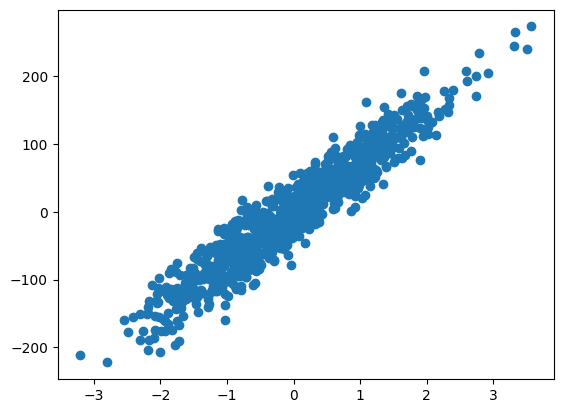

In [8]:
plt.scatter(X,y)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

LinearRegression()

In [12]:
lr.coef_

array([72.64822827])

In [13]:
lr.intercept_

np.float64(-0.1522258920873334)

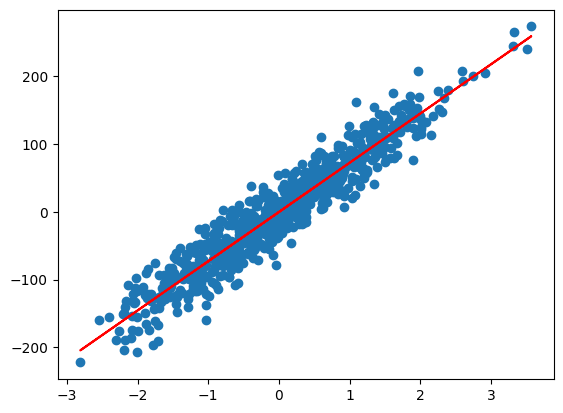

In [14]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train),color='red')

In [15]:
class MYLR:
   def __init__(self):
    self.coef_ = None
    self.intercept_ = None

   def fit(self,X_train,y_train):
    num = 0
    dem = 0

    for i in range(X_train.shape[0]):
       num = num + ((X_train[i]-X_train.mean())*(y_train[i]-y_train.mean()))
       dem = dem + ((X_train[i]-X_train.mean())*(X_train[i]-X_train.mean()))

       self.coef_ = num /dem
       self.intercept_ = y_train.mean()-(self.coef_ * X_train.mean())

    print(self.coef_)
    print(self.intercept_)

   def predict(self,X_test):
    return self.coef_ * X_test + self.intercept_


In [16]:
lr2 = MYLR()

lr2.fit(X_train,y_train)

[72.64822827]
[-0.15222589]


In [17]:
y_pred = lr2.predict(X_test)

In [18]:
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8864257475778738
633.0390081523893


In [19]:
#calculating the adjusted r2 error
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
print(adjusted_r2)

0.8858521402424085


In [20]:
#code for multiple regression
from sklearn.datasets import load_diabetes

In [21]:
X , y = load_diabetes(return_X_y=True)

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [23]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [24]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [25]:
reg.intercept_

np.float64(151.88331005254167)

In [26]:
r2_score(y_test,reg.predict(X_test))

0.4399338661568968

In [27]:
class MeraLreg:
  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1)

    #calculating the coefficents
    betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
    self.intercept_ = betas[0]
    self.coef_ = betas[1:]

  def predict(self,X_test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred

In [28]:
lr = MeraLreg()
lr.fit(X_train,y_train)
X_train.shape

(353, 10)

In [29]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [30]:
X,y = load_diabetes(return_X_y=True)

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [32]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [33]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [34]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [35]:
class GDRegressor:

    def __init__(self,learning_rate=0.01,epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)

            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [36]:
gdr = GDRegressor(epochs=1000,learning_rate=0.5)

In [37]:
gdr.fit(X_train,y_train)

152.01351687661833 [  14.38990585 -173.7235727   491.54898524  323.91524824  -39.32648042
 -116.01061213 -194.04077415  103.38135565  451.63448787   97.57218278]


In [38]:
y_pred = gdr.predict(X_test)
r2_score(y_test,y_pred)

0.4534503034722803

In [39]:
from sklearn.linear_model import Ridge

In [40]:
X , y = load_diabetes(return_X_y=True)

In [62]:
rg = Ridge(alpha=8)

In [63]:
rg.fit(X_train,y_train)

Ridge(alpha=8)

In [64]:
rg.alpha

8

In [65]:

rg.coef_

array([ 24.58947322,   0.95691475,  76.43496137,  57.96817727,
        20.90056673,  14.03048714, -46.1825351 ,  45.44825533,
        73.64528054,  41.73871874])

In [66]:
rg.intercept_

np.float64(150.9780121842314)

In [67]:
y_pred = rg.predict(X_test)

In [68]:
r2_score(y_test,y_pred)

0.17822306419536882